# IMPORT LIBRARY

In [ ]:
!pip install Sastrawi

In [20]:
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed) # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory # Stopword removal (penghilangan kata-kata umum yang tidak memiliki makna penting) dalam bahasa Indonesia

from wordcloud import WordCloud
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Scraping Dataset

In [21]:
# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews_all, Sort

# Mengambil semua ulasan dari aplikasi dengan ID 'com.byu.id' di Google Play Store.
# Proses scraping mungkin memerlukan beberapa saat tergantung pada jumlah ulasan yang ada.

scrapview = reviews_all(
    'com.byu.id', # ID aplikasi
    lang = 'id', #Bahasa ulasan
    country = 'id', #Negara
    sort = Sort.MOST_RELEVANT, #Urutan ulasan berdasarkan relevansi
    count = 1000 #Jumlah ulasan yang diambil
)
scrapview

[{'reviewId': 'a6855ffa-e317-451a-a33e-cb152c563b2d',
  'userName': 'Pengguna Google',
  'userImage': 'https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g',
  'content': 'Aplikasinya sering lelet kalo dibuka. Paket datanya agak mahal dari provider lain, sinyalnya kenceng buat download tapi ga stabil kadang bisa 5G, kadang ke 4G+, 4G, kalo cuaca lagi jelek kadang malah gaada sinyal/E. Masa kalah sama Three sama XL (di HP satunya) sinyalnya makin kesini makin meningkat, udah jarang banget nemu kendala. Ini baru nyoba byU malah dah dikasih kesan buruk. Ditingkatin lah minimal aplikasinya kalo dibuka gampang cepet masuknya, padahal dah dapet nomer bagus -_-',
  'score': 3,
  'thumbsUpCount': 6,
  'reviewCreatedVersion': '1.64.3',
  'at': datetime.datetime(2026, 3, 19, 10, 2, 48),
  'replyContent': 'Hallo Kak, maaf banget yaa terkait kendalanya, bisa coba ubah mode jaringan dari otomatis ke manual 2g only, terus balikin la

In [22]:
import csv

with open('ulasan_aplikasi.csv', 'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])
    for review in scrapview:
        writer.writerow([review['content']])

# Loading Dataset
Selanjutnya, jika sudah berhasil, kita dapat melihat dataset tersebut dengan kode seperti berikut.



In [23]:
app_reviews_df = pd.DataFrame(scrapview)
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a6855ffa-e317-451a-a33e-cb152c563b2d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasinya sering lelet kalo dibuka. Paket da...,3,6,1.64.3,2026-03-19 10:02:48,"Hallo Kak, maaf banget yaa terkait kendalanya,...",2026-03-19 10:13:50,1.64.3
1,f177e111-91e0-4f2a-a2b6-0f44f322c302,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat mengecewakan..!! pakai byu hampir 4thn....,1,5,1.64.3,2026-03-21 15:24:54,"Hallo Kak, maaf banget yaa terkait kendalanya,...",2026-03-21 15:57:32,1.64.3
2,0c81dbb0-3c40-4407-a5e7-52def7930a38,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"pas awal pake ngerasa puas banget, selain mura...",1,7,1.64.3,2026-03-24 07:54:08,"Hai Kak Fenita , maaf nih terkait kendalanya, ...",2026-03-24 07:55:17,1.64.3
3,bb2ca468-0944-40c0-83e0-cabec25ce8c9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya jarang mengajukan komplain kemanapun, tap...",1,8,1.64.3,2026-03-13 01:35:27,"Hai Kak, maaf ya udah bikin ga nyaman :( Terka...",2026-03-13 02:07:17,1.64.3
4,4c2444df-eb0a-496a-b791-38207e826195,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi sering error. Pulsa sudah ada, mau be...",1,8,1.64.3,2026-03-16 03:02:51,"Hai Kak Repa , maaf udah bikin ga nyaman ya :(...",2026-03-16 07:39:39,1.64.3


In [24]:
app_reviews_df = pd.DataFrame(scrapview)
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

app_reviews_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a6855ffa-e317-451a-a33e-cb152c563b2d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasinya sering lelet kalo dibuka. Paket da...,3,6,1.64.3,2026-03-19 10:02:48,"Hallo Kak, maaf banget yaa terkait kendalanya,...",2026-03-19 10:13:50,1.64.3
1,f177e111-91e0-4f2a-a2b6-0f44f322c302,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat mengecewakan..!! pakai byu hampir 4thn....,1,5,1.64.3,2026-03-21 15:24:54,"Hallo Kak, maaf banget yaa terkait kendalanya,...",2026-03-21 15:57:32,1.64.3
2,0c81dbb0-3c40-4407-a5e7-52def7930a38,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"pas awal pake ngerasa puas banget, selain mura...",1,7,1.64.3,2026-03-24 07:54:08,"Hai Kak Fenita , maaf nih terkait kendalanya, ...",2026-03-24 07:55:17,1.64.3
3,bb2ca468-0944-40c0-83e0-cabec25ce8c9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya jarang mengajukan komplain kemanapun, tap...",1,8,1.64.3,2026-03-13 01:35:27,"Hai Kak, maaf ya udah bikin ga nyaman :( Terka...",2026-03-13 02:07:17,1.64.3
4,4c2444df-eb0a-496a-b791-38207e826195,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi sering error. Pulsa sudah ada, mau be...",1,8,1.64.3,2026-03-16 03:02:51,"Hai Kak Repa , maaf udah bikin ga nyaman ya :(...",2026-03-16 07:39:39,1.64.3
...,...,...,...,...,...,...,...,...,...,...,...
217843,536dae46-6174-4860-aa6a-cb0f76691a79,TRIO KANJUT,https://play-lh.googleusercontent.com/a/ACg8oc...,. . ...,1,0,None,2024-08-14 06:50:08,"Hi, Kak. Maaf banget jadi bikin gak nyaman. Ni...",2024-08-14 15:25:52,None
217844,30067283-6077-4c9c-8106-6688d0aa7dcf,Tarmizi Fadilah,https://play-lh.googleusercontent.com/a-/ALV-U...,??????????????preet,1,0,None,2020-11-22 12:23:05,Hai Kak! Maaf ketidaknyamanannya. Jika berkend...,2020-11-25 02:50:02,None
217845,c2de2d80-ffae-4899-af0d-3151a5b325f9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,😊,2,0,None,2020-01-29 06:58:41,"Hai Kak maaf ketidaknyamanannya, untuk kendala...",2020-01-29 06:52:44,None
217846,c1f87866-c18d-4e31-8ce9-55ce683aea5a,Laila Fitriana,https://play-lh.googleusercontent.com/a/ACg8oc...,😙😙,2,0,None,2021-10-25 22:47:21,Hai kak. Makasih buat feedback dan sarannya ya...,2021-10-25 22:49:41,None


In [25]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217848 entries, 0 to 217847
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              217848 non-null  object        
 1   userName              217848 non-null  object        
 2   userImage             217848 non-null  object        
 3   content               217847 non-null  object        
 4   score                 217848 non-null  int64         
 5   thumbsUpCount         217848 non-null  int64         
 6   reviewCreatedVersion  180968 non-null  object        
 7   at                    217848 non-null  datetime64[ns]
 8   replyContent          196678 non-null  object        
 9   repliedAt             196678 non-null  datetime64[ns]
 10  appVersion            180968 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 18.3+ MB


In [26]:
clean_df  = app_reviews_df.dropna()
clean_df = clean_df.drop_duplicates()

In [27]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162604 entries, 0 to 209563
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              162604 non-null  object        
 1   userName              162604 non-null  object        
 2   userImage             162604 non-null  object        
 3   content               162604 non-null  object        
 4   score                 162604 non-null  int64         
 5   thumbsUpCount         162604 non-null  int64         
 6   reviewCreatedVersion  162604 non-null  object        
 7   at                    162604 non-null  datetime64[ns]
 8   replyContent          162604 non-null  object        
 9   repliedAt             162604 non-null  datetime64[ns]
 10  appVersion            162604 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 14.9+ MB


In [28]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) #menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) #menghapus hastag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) #menghapus URL
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') #menganti garis baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) #menghapus tanda baca
    text = text.strip(' ')      #menghapus spasi di awal dan akhir teks
    return text

def casefoldingText(text): 
    text = text.lower() #mengubah semua huruf menjadi huruf kecil
    return text

def tokenizingText(text):
    teks = word_tokenize(text)
    return teks

def filteringText(text):
    listStopWords = set(stopwords.words('indonesian')) #mengambil daftar stopword bahasa Indonesia
    listStopWords = set(stopwords.words('english'))
    listStopWords.update(['yg', 'dg', 'rt', 'dgn', 'ny', 'klo', 'kalo', 'amp', 'biar', 'bikin', 'bilang', 'gak', 'ga', 'krn', 'nya', 'nih', 'sih', 'si', 'tau', 'tuh', 'utk', 'ya', 'jd', 'jdi'])
    filtered = []
    for txt in text:
        if txt not in listStopWords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    #memecah teks menjadi kata-kata
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    stemmed_text = ' '.join(stemmed_words)
    return stemmed_text

def toSentence(text):
    sentence =' '.join(word for word in text)
    return sentence

In [29]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []
 
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
 
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [30]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
 
# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
 
# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
 
# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
 
# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
 
# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [67]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,a6855ffa-e317-451a-a33e-cb152c563b2d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasinya sering lelet kalo dibuka. Paket da...,3,6,1.64.3,2026-03-19 10:02:48,"Hallo Kak, maaf banget yaa terkait kendalanya,...",2026-03-19 10:13:50,1.64.3,Aplikasinya sering lelet kalo dibuka Paket dat...,aplikasinya sering lelet kalo dibuka paket dat...,aplikasinya sering lelet kalo dibuka paket dat...,"[aplikasinya, sering, lelet, kalo, dibuka, pak...","[aplikasinya, sering, lelet, dibuka, paket, da...",aplikasinya sering lelet dibuka paket datanya ...
1,f177e111-91e0-4f2a-a2b6-0f44f322c302,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat mengecewakan..!! pakai byu hampir 4thn....,1,5,1.64.3,2026-03-21 15:24:54,"Hallo Kak, maaf banget yaa terkait kendalanya,...",2026-03-21 15:57:32,1.64.3,sangat mengecewakan pakai byu hampir thn kukir...,sangat mengecewakan pakai byu hampir thn kukir...,sangat mengecewakan pakai byu hampir thn kukir...,"[sangat, mengecewakan, pakai, byu, hampir, thn...","[sangat, mengecewakan, pakai, byu, hampir, thn...",sangat mengecewakan pakai byu hampir thn kukir...
2,0c81dbb0-3c40-4407-a5e7-52def7930a38,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"pas awal pake ngerasa puas banget, selain mura...",1,7,1.64.3,2026-03-24 07:54:08,"Hai Kak Fenita , maaf nih terkait kendalanya, ...",2026-03-24 07:55:17,1.64.3,pas awal pake ngerasa puas banget selain murah...,pas awal pake ngerasa puas banget selain murah...,pas awal pake ngerasa puas banget selain murah...,"[pas, awal, pake, ngerasa, puas, banget, selai...","[pas, awal, pake, ngerasa, puas, banget, selai...",pas awal pake ngerasa puas banget selain murah...
3,bb2ca468-0944-40c0-83e0-cabec25ce8c9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya jarang mengajukan komplain kemanapun, tap...",1,8,1.64.3,2026-03-13 01:35:27,"Hai Kak, maaf ya udah bikin ga nyaman :( Terka...",2026-03-13 02:07:17,1.64.3,saya jarang mengajukan komplain kemanapun tapi...,saya jarang mengajukan komplain kemanapun tapi...,saya jarang mengajukan komplain kemanapun tapi...,"[saya, jarang, mengajukan, komplain, kemanapun...","[saya, jarang, mengajukan, komplain, kemanapun...",saya jarang mengajukan komplain kemanapun tapi...
4,4c2444df-eb0a-496a-b791-38207e826195,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi sering error. Pulsa sudah ada, mau be...",1,8,1.64.3,2026-03-16 03:02:51,"Hai Kak Repa , maaf udah bikin ga nyaman ya :(...",2026-03-16 07:39:39,1.64.3,Aplikasi sering error Pulsa sudah ada mau beli...,aplikasi sering error pulsa sudah ada mau beli...,aplikasi sering error pulsa sudah ada mau beli...,"[aplikasi, sering, error, pulsa, sudah, ada, m...","[aplikasi, sering, error, pulsa, sudah, ada, m...",aplikasi sering error pulsa sudah ada mau beli...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209554,cd5f5eaf-f7fa-4619-b4ec-4f8f627d0cbe,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Oke,5,0,1.0.318 - by.U,2019-10-25 12:44:20,Hi kak makasi yah buat support nya :),2019-10-28 02:42:49,1.0.318 - by.U,Oke,oke,oke,[oke],[oke],oke
209558,5d3c977c-f441-4278-be52-69d670684a58,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ga bsa dafatar via fb,1,1,1.0.313,2019-10-19 09:02:35,"hai hai, untuk troubleshoot solution bisa hubu...",2019-10-19 11:22:14,1.0.313,Ga bsa dafatar via fb,ga bsa dafatar via fb,ga bsa dafatar via fb,"[ga, bsa, dafatar, via, fb]","[bsa, dafatar, via, fb]",bsa dafatar via fb
209559,a81ed629-6cc7-4a68-8d9f-fe527924dab2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Gak bisa sign up atau log in,1,1,1.0.313,2019-10-18 19:43:03,"Hi kak,\nNindy mohon maap yaaa, kita emang sem...",2019-10

# PELABELAN
Sebelum masuk ke tahap pemodelan, langkah yang dilakukan adalah pelabelan. Pelabelan adalah proses pemberian kategori atau label pada setiap entri data berdasarkan informasi yang tersedia. Dalam konteks ini, setiap entri dataset diberikan label sentimen berdasarkan analisis teksnya. Dengan demikian, tahapan pelabelan menjadi dasar untuk proses selanjutnya dalam membangun model klasifikasi sentimen.

In [104]:
import csv 
import requests
from io import StringIO

lexicon_positive = dict()
response = requests.get(('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'))

if response.status_code == 200:
     # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader :
         # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
        lexicon_positive[row[0]] = int(row[1])

else :
    print("Failed to fetch positive lexicon data")
        
lexicon_negative = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader :
        lexicon_negative[row[0]] = int(row[1])

else : 
    print("Failed to fetch negative lexicon data")

In [122]:
def sentiment_analysis_lexicon_indonesia(text):
    #inisialisasi skor sentimen
    score = 0

    for word in text:
        if word in lexicon_positive:
             # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen
             score = score + lexicon_positive[word]
    
    for word in text:
        if word in lexicon_negative:
            # Jika kata ada dalam kamus negatif, tambahkan skornya ke skor sentimen
            score = score + lexicon_negative[word]
        
    polarity = ''

    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [129]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    84634
positive    54483
neutral     23487
Name: count, dtype: int64


In [130]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity
0,a6855ffa-e317-451a-a33e-cb152c563b2d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasinya sering lelet kalo dibuka. Paket da...,3,6,1.64.3,2026-03-19 10:02:48,"Hallo Kak, maaf banget yaa terkait kendalanya,...",2026-03-19 10:13:50,1.64.3,Aplikasinya sering lelet kalo dibuka Paket dat...,aplikasinya sering lelet kalo dibuka paket dat...,aplikasinya sering lelet kalo dibuka paket dat...,"[aplikasinya, sering, lelet, kalo, dibuka, pak...","[aplikasinya, sering, lelet, dibuka, paket, da...",aplikasinya sering lelet dibuka paket datanya ...,-3,negative
1,f177e111-91e0-4f2a-a2b6-0f44f322c302,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat mengecewakan..!! pakai byu hampir 4thn....,1,5,1.64.3,2026-03-21 15:24:54,"Hallo Kak, maaf banget yaa terkait kendalanya,...",2026-03-21 15:57:32,1.64.3,sangat mengecewakan pakai byu hampir thn kukir...,sangat mengecewakan pakai byu hampir thn kukir...,sangat mengecewakan pakai byu hampir thn kukir...,"[sangat, mengecewakan, pakai, byu, hampir, thn...","[sangat, mengecewakan, pakai, byu, hampir, thn...",sangat mengecewakan pakai byu hampir thn kukir...,1,positive
2,0c81dbb0-3c40-4407-a5e7-52def7930a38,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"pas awal pake ngerasa puas banget, selain mura...",1,7,1.64.3,2026-03-24 07:54:08,"Hai Kak Fenita , maaf nih terkait kendalanya, ...",2026-03-24 07:55:17,1.64.3,pas awal pake ngerasa puas banget selain murah...,pas awal pake ngerasa puas banget selain murah...,pas awal pake ngerasa puas banget selain murah...,"[pas, awal, pake, ngerasa, puas, banget, selai...","[pas, awal, pake, ngerasa, puas, banget, selai...",pas awal pake ngerasa puas banget selain murah...,-6,negative
3,bb2ca468-0944-40c0-83e0-cabec25ce8c9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya jarang mengajukan komplain kemanapun, tap...",1,8,1.64.3,2026-03-13 01:35:27,"Hai Kak, maaf ya udah bikin ga nyaman :( Terka...",2026-03-13 02:07:17,1.64.3,saya jarang mengajukan komplain kemanapun tapi...,saya jarang mengajukan komplain kemanapun tapi...,saya jarang mengajukan komplain kemanapun tapi...,"[saya, jarang, mengajukan, komplain, kemanapun...","[saya, jarang, mengajukan, komplain, kemanapun...",saya jarang mengajukan komplain kemanapun tapi...,-55,negative
4,4c2444df-eb0a-496a-b791-38207e826195,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi sering error. Pulsa sudah ada, mau be...",1,8,1.64.3,2026-03-16 03:02:51,"Hai Kak Repa , maaf udah bikin ga nyaman ya :(...",2026-03-16 07:39:39,1.64.3,Aplikasi sering error Pulsa sudah ada mau beli...,aplikasi sering error pulsa sudah ada mau beli...,aplikasi sering error pulsa sudah ada mau beli...,"[aplikasi, sering, error, pulsa, sudah, ada, m...","[aplikasi, sering, error, pulsa, sudah, ada, m...",aplikasi sering error pulsa sudah ada mau beli...,-41,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209554,cd5f5eaf-f7fa-4619-b4ec-4f8f627d0cbe,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Oke,5,0,1.0.318 - by.U,2019-10-25 12:44:20,Hi kak makasi yah buat support nya :),2019-10-28 02:42:49,1.0.318 - by.U,Oke,oke,oke,[oke],[oke],oke,2,positive
209558,5d3c977c-f441-4278-be52-69d670684a58,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ga bsa dafatar via fb,1,1,1.0.313,2019-10-19 09:02:35,"hai hai, untuk troubleshoot solution bisa hubu...",2019-10-19 11:22:14,1.0.313,Ga bsa dafatar via fb,ga bsa dafatar via fb,ga bsa dafatar via fb,"[ga, bsa, dafatar, via, fb]","[bsa, dafatar, via, fb]",bsa dafatar via fb,0,neutral
209559,a81ed629-6cc7-4a68-8d9f-fe527924dab2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Gak bi

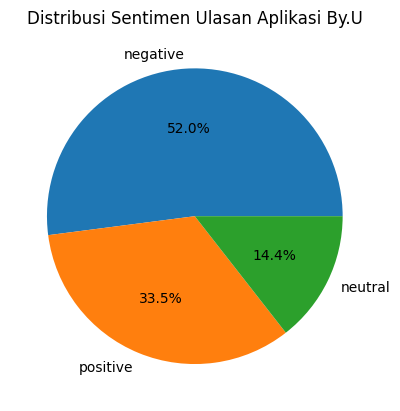

In [148]:
plt.pie(clean_df['polarity'].value_counts(), labels=clean_df['polarity'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribusi Sentimen Ulasan Aplikasi By.U')
plt.show()

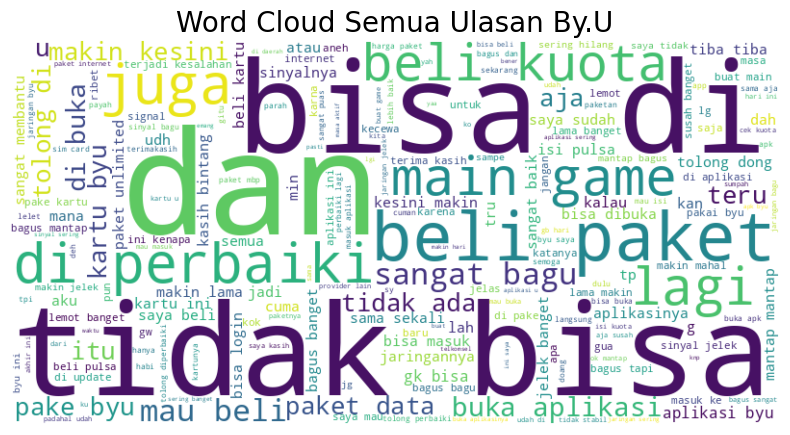

In [154]:
from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS)

all_text = ' '.join(clean_df['text_akhir'])

wc = WordCloud(background_color='white', width=800, height=400, stopwords=stopwords)
wc.generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Semua Ulasan By.U', fontsize=20)
plt.show()